In [1]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
import random
import numpy as np
import torch

initial_offset = 42

np.random.seed(initial_offset)
random.seed(initial_offset)

torch.manual_seed(initial_offset)
torch.cuda.manual_seed_all(initial_offset)

setattr(torch.backends.cudnn, 'deterministic', True)
torch.backends.cudnn.benchmark = False

In [ ]:
current_env = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device(current_env)

print(f"Hardware in use: {device}")

Hardware in use: cuda


In [4]:
!pip install -q timm


In [ ]:
import os
import timm
from PIL import Image
from tqdm.auto import tqdm  

import torch
import torch.nn as nn
import torch.nn.functional as F

# Image processing
from torchvision import transforms as T

In [ ]:
import matplotlib.pyplot as plt

import sklearn.metrics as metrics
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve

In [ ]:
print(f"Running PyTorch: {torch.__version__}")
print(f"GPU active: {torch.cuda.is_available()}")

if 'timm' in globals() or 'timm' in locals():
    print("timm module: Ready")

Running PyTorch: 2.9.0+cu126
GPU active: True
timm module: Ready


In [ ]:
project_path = "/content/drive/MyDrive/morph_project/extracted_datasets/CASIA2"

real_imgs_path = os.path.join(project_path, "Au")
fake_imgs_path = os.path.join(project_path, "Tp")

for folder, path in {"Authentic": real_imgs_path, "Tampered": fake_imgs_path}.items():
    status = "Found" if os.path.exists(path) else "Missing"
    print(f"{folder} Source: {status}")

Authentic Source: Found
Tampered Source: Found


In [ ]:
def collect_filepaths(target_dir):
    valid_formats = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    path_list = []

    for entry in os.listdir(target_dir):
        _, file_ext = os.path.splitext(entry)
        if file_ext.lower() in valid_formats:
            full_path = os.path.join(target_dir, entry)
            path_list.append(full_path)

    return path_list

au_images = collect_filepaths(real_imgs_path)
tp_images = collect_filepaths(fake_imgs_path)

print(f"Loaded {len(au_images)} authentic samples.")
print(f"Loaded {len(tp_images)} tampered samples.")

Loaded 7491 authentic samples.
Loaded 1553 tampered samples.


In [ ]:
from sklearn.model_selection import train_test_split

labels_0 = [0 for _ in range(len(au_images))]
labels_1 = [1 for _ in range(len(tp_images))]

# Merge paths and labels into unified lists
data_pool = au_images + tp_images
label_pool = labels_0 + labels_1

split_results = train_test_split(
    data_pool,
    label_pool,
    test_size=0.20,
    stratify=label_pool,
    random_state=initial_offset
)

_, test_images, _, test_labels = split_results

In [ ]:
final_labels = np.asarray(test_labels)

print(f"Total test samples: {len(test_images)}")

unique_vals, occurrence_counts = np.unique(final_labels, return_counts=True)
for val, count in zip(unique_vals, occurrence_counts):
    label_name = "Authentic" if val == 0 else "Tampered"
    print(f"Count for {label_name} ({val}): {count}")

Total test samples: 1809
Count for Authentic (0): 1498
Count for Tampered (1): 311


In [ ]:
test_data_map = {0: [], 1: []}

for path, category in zip(test_images, test_labels):
    test_data_map[int(category)].append(path)

test_au = test_data_map[0]
test_tp = test_data_map[1]

print(f"Validation - Real Samples: {len(test_au)}")
print(f"Validation - Edited Samples: {len(test_tp)}")

Validation - Real Samples: 1498
Validation - Edited Samples: 311


In [ ]:
img_size = (224, 224)
norm_stats = ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

inference_transform = T.Compose([
    T.Resize(img_size),
    T.ToTensor(),
    T.Normalize(*norm_stats)
])

In [ ]:
def prepare_input(path, target_device):
    """Loads and formats an image for model prediction"""
    with Image.open(path) as raw_img:
        img_rgb = raw_img.convert("RGB")

    tensor_data = inference_transform(img_rgb).unsqueeze(0)

    return tensor_data.to(target_device)

In [ ]:
example_path = test_images[0]
input_tensor = prepare_input(example_path, device)

print(f"Tensor Shape: {list(input_tensor.shape)}")
print(f"Allocated on: {input_tensor.device}")

val_range = (input_tensor.min().item(), input_tensor.max().item())
print("Value extremes (Min, Max): %.4f, %.4f" % val_range)

Tensor Shape: [1, 3, 224, 224]
Allocated on: cuda:0
Value extremes (Min, Max): -2.1179, 1.9384


In [ ]:
weights_dir = "/content/drive/MyDrive/morph_project"

model_checkpoints = {
    "vit": f"{weights_dir}/models/vit_advanced.pth",
    "effnet": f"{weights_dir}/models/efficientnet_b3_tuned_baseline.pth",
    "convnext": f"{weights_dir}/models/convnextv2_best_224_finetuned.pth",
    "swin": f"{weights_dir}/swin224_recall_tuned.pth"
}



In [ ]:
for model_name, file_path in model_checkpoints.items():
    found = "OK" if os.path.exists(file_path) else "MISSING"
    print(f"[{model_name.upper()}] Status: {found}")

    if found == "MISSING":
        print(f"Warning: Check path {file_path}")

[VIT] Status: OK
[EFFNET] Status: OK
[CONVNEXT] Status: OK
[SWIN] Status: OK


In [ ]:
def sync_model_weights(net, path):
    raw_data = torch.load(path, map_location="cpu")

    params = raw_data.get("state_dict", raw_data) if isinstance(raw_data, dict) else raw_data

    adjusted_weights = {}
    for key, value in params.items():
        clean_key = key.split("backbone.")[-1]
        adjusted_weights[clean_key] = value

    info = net.load_state_dict(adjusted_weights, strict=False)

    print(f"\nCheckpoint: {os.path.basename(path)}")
    print(f"Status -> Missing: {len(info.missing_keys)} | Unexpected: {len(info.unexpected_keys)}")

In [ ]:
vit_model = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=2)

sync_model_weights(vit_model, model_checkpoints["vit"])

vit_model.to(device).eval()

print("ViT model initialized and set to evaluation mode.")


Checkpoint: vit_advanced.pth
Status -> Missing: 0 | Unexpected: 0
ViT model initialized and set to evaluation mode.


In [ ]:
eff_model = timm.create_model("efficientnet_b3", pretrained=False, num_classes=2)

sync_model_weights(eff_model, model_checkpoints["effnet"])

eff_model.to(device)
eff_model.train(False) 

print(f"EfficientNet-B3 ready on {device}")


Checkpoint: efficientnet_b3_tuned_baseline.pth
Status -> Missing: 0 | Unexpected: 0
EfficientNet-B3 ready on cuda


In [ ]:
conv_model = timm.create_model("convnextv2_tiny", pretrained=False, num_classes=2)

sync_model_weights(conv_model, model_checkpoints["convnext"])

conv_model.eval()
if torch.cuda.is_available():
    conv_model.cuda() 

print("ConvNextV2 model is live.")


Checkpoint: convnextv2_best_224_finetuned.pth
Status -> Missing: 2 | Unexpected: 4
ConvNextV2 model is live.


In [ ]:
swin_model = timm.create_model("swin_tiny_patch4_window7_224",
                               pretrained=False,
                               num_classes=2)

sync_model_weights(swin_model, model_checkpoints["swin"])

swin_model.requires_grad_(False) 
swin_model.to(device)
swin_model.eval()

print(f"Swin-T: Setup complete on {device.type.upper()}")


Checkpoint: swin224_recall_tuned.pth
Status -> Missing: 2 | Unexpected: 4
Swin-T: Setup complete on CUDA


In [ ]:
sample_input = prepare_input(test_images[0], device)

model_suite = {
    "ViT": vit_model,
    "EfficientNet": eff_model,
    "ConvNeXt": conv_model,
    "Swin": swin_model
}

with torch.inference_mode(): # Modern alternative to no_grad
    for name, net in model_suite.items():
        prediction = net(sample_input)
        print(f"[{name:12}] Output Dimensions: {list(prediction.shape)}")

[ViT         ] Output Dimensions: [1, 2]
[EfficientNet] Output Dimensions: [1, 2]
[ConvNeXt    ] Output Dimensions: [1, 2]
[Swin        ] Output Dimensions: [1, 2]


In [ ]:
def run_benchmark(net, title):
    """Gathers performance metrics for a specific architecture"""
    results_cache = []
    ground_truth = []

    for path, target in tqdm(zip(test_images, test_labels),
                            total=len(test_images),
                            desc=f"Testing {title}"):

        blob = prepare_input(path, device)
        with torch.inference_mode():
            raw_output = net(blob)
            probabilities = torch.softmax(raw_output, dim=1).squeeze().cpu().numpy()

        ground_truth.append(target)
        results_cache.append((probabilities.argmax(), probabilities[1]))

    preds, scores = zip(*results_cache)

    return {
        "acc": accuracy_score(ground_truth, preds),
        "prec": precision_score(ground_truth, preds, zero_division=0),
        "rec": recall_score(ground_truth, preds),
        "f1_score": f1_score(ground_truth, preds),
        "auc_val": roc_auc_score(ground_truth, scores),
        "cm": confusion_matrix(ground_truth, preds)
    }

In [ ]:
all_model_results = {}

eval_queue = {
    "VisionTransformer": vit_model,
    "EffNet_B3": eff_model,
    "ConvNeXt_V2": conv_model,
    "Swin_T": swin_model
}

for label, net in eval_queue.items():
    all_model_results[label] = run_benchmark(net, label)


Testing VisionTransformer:   0%|          | 0/1809 [00:00<?, ?it/s]

Testing EffNet_B3:   0%|          | 0/1809 [00:00<?, ?it/s]

Testing ConvNeXt_V2:   0%|          | 0/1809 [00:00<?, ?it/s]

Testing Swin_T:   0%|          | 0/1809 [00:00<?, ?it/s]

In [ ]:
def display_report(model_tag, stats):
    """Prints a formatted summary of classification performance"""
    print(f"\n>>> Performance Report: {model_tag.upper()} <<<")

    metric_labels = {
        "Accuracy": "acc",
        "Precision": "prec",
        "Recall": "rec",
        "F1-Score": "f1_score",
        "AUC": "auc_val"
    }

    for label, key in metric_labels.items():
        print(f"{label:10} | {stats[key]:.4f}")

    print("\nConfusion Matrix:")
    print(stats["cm"])

In [28]:
for title, data in all_model_results.items():
    display_report(title, data)


>>> Performance Report: VISIONTRANSFORMER <<<
Accuracy   | 0.9132
Precision  | 0.7104
Recall     | 0.8360
F1-Score   | 0.7681
AUC        | 0.9474

Confusion Matrix:
[[1392  106]
 [  51  260]]

>>> Performance Report: EFFNET_B3 <<<
Accuracy   | 0.4378
Precision  | 0.1914
Recall     | 0.7042
F1-Score   | 0.3010
AUC        | 0.5511

Confusion Matrix:
[[573 925]
 [ 92 219]]

>>> Performance Report: CONVNEXT_V2 <<<
Accuracy   | 0.4190
Precision  | 0.1749
Recall     | 0.6399
F1-Score   | 0.2747
AUC        | 0.4895

Confusion Matrix:
[[559 939]
 [112 199]]

>>> Performance Report: SWIN_T <<<
Accuracy   | 0.5368
Precision  | 0.1859
Recall     | 0.5016
F1-Score   | 0.2713
AUC        | 0.5426

Confusion Matrix:
[[815 683]
 [155 156]]


In [ ]:
for model_key, results_data in all_model_results.items():
    display_report(model_key, results_data)
    print("-" * 30) 


>>> Performance Report: VISIONTRANSFORMER <<<
Accuracy   | 0.9132
Precision  | 0.7104
Recall     | 0.8360
F1-Score   | 0.7681
AUC        | 0.9474

Confusion Matrix:
[[1392  106]
 [  51  260]]
------------------------------

>>> Performance Report: EFFNET_B3 <<<
Accuracy   | 0.4378
Precision  | 0.1914
Recall     | 0.7042
F1-Score   | 0.3010
AUC        | 0.5511

Confusion Matrix:
[[573 925]
 [ 92 219]]
------------------------------

>>> Performance Report: CONVNEXT_V2 <<<
Accuracy   | 0.4190
Precision  | 0.1749
Recall     | 0.6399
F1-Score   | 0.2747
AUC        | 0.4895

Confusion Matrix:
[[559 939]
 [112 199]]
------------------------------

>>> Performance Report: SWIN_T <<<
Accuracy   | 0.5368
Precision  | 0.1859
Recall     | 0.5016
F1-Score   | 0.2713
AUC        | 0.5426

Confusion Matrix:
[[815 683]
 [155 156]]
------------------------------


In [ ]:

performance_weights = {
    "rec": 0.5,
    "auc_val": 0.3,
    "prec": 0.2
}

model_rankings = {}

for label, metrics in all_model_results.items():
    composite_score = sum(metrics[k] * w for k, w in performance_weights.items())
    model_rankings[label] = round(composite_score, 4)

model_rankings

{'VisionTransformer': np.float64(0.8443),
 'EffNet_B3': np.float64(0.5557),
 'ConvNeXt_V2': np.float64(0.5018),
 'Swin_T': np.float64(0.4508)}

In [ ]:
aggregate_performance = sum(model_rankings.values())

ensemble_ratios = {
    tag: (val / aggregate_performance)
    for tag, val in model_rankings.items()
}

ensemble_ratios

{'VisionTransformer': np.float64(0.3588795375329423),
 'EffNet_B3': np.float64(0.23620674997874694),
 'ConvNeXt_V2': np.float64(0.2132959279095469),
 'Swin_T': np.float64(0.19161778457876394)}

In [ ]:
header = "MODEL CONTRIBUTION SUMMARY"
print(f"\n{'='*len(header)}\n{header}\n{'='*len(header)}")

for model_id, ratio in ensemble_ratios.items():
    print(f"| {model_id:20} | {ratio:>8.4f} |")

print('='*len(header))


MODEL CONTRIBUTION SUMMARY
| VisionTransformer    |   0.3589 |
| EffNet_B3            |   0.2362 |
| ConvNeXt_V2          |   0.2133 |
| Swin_T               |   0.1916 |


In [ ]:
class EnsembleClassifier(nn.Module):
    def __init__(self, model_map, weight_map):
       
        super().__init__()
        self.sub_models = nn.ModuleDict(model_map)
        self.ratios = weight_map

    def forward(self, tensor_in):
        weighted_predictions = []

        for key, net in self.sub_models.items():
            raw_logits = net(tensor_in)
            proba = torch.softmax(raw_logits, dim=1)

            weighted_predictions.append(proba * self.ratios[key])

        return torch.stack(weighted_predictions).sum(dim=0)

In [ ]:
ensemble_net = EnsembleClassifier(
    model_map=eval_queue,
    weight_map=ensemble_ratios
)

ensemble_net.to(device)
ensemble_net.eval()

print(f"Ensemble logic finalized. Running on: {device}")

Ensemble logic finalized. Running on: cuda


In [35]:
# Select a test sample and prepare it
test_blob = prepare_input(test_images[0], device)

# Run a combined inference across all models
with torch.inference_mode():
    ensemble_output = ensemble_net(test_blob)

# View the final consensus
final_probs = ensemble_output.squeeze().cpu().numpy()
predicted_idx = final_probs.argmax()

print(f"Ensemble Prediction: Class {predicted_idx}")
print(f"Consensus Probabilities: {final_probs}")
print(f"Output Tensor Shape: {list(ensemble_output.shape)}")

Ensemble Prediction: Class 0
Consensus Probabilities: [0.5135391 0.4864609]
Output Tensor Shape: [1, 2]


In [ ]:
def classify_sample(file_path):
    """
    Higher-level wrapper to run the ensemble on a single file path.
    """
    input_data = prepare_input(file_path, device)

    with torch.inference_mode():
        soft_probs = ensemble_net(input_data).squeeze(0) # Remove batch dim

    score, class_id = torch.max(soft_probs, dim=0)

    class_map = {0: "Authentic (Licit)", 1: "Tampered (Illicit)"}

    return {
        "verdict": class_map[class_id.item()],
        "confidence": score.item(),
        "distribution": soft_probs.cpu().numpy()
    }

In [ ]:
from pathlib import Path

export_path = Path("/content/drive/MyDrive/morph_project/fusion/final_weighted_soft_voting_ensemble.pth")

export_path.parent.mkdir(parents=True, exist_ok=True)

ENSEMBLE_SAVE_PATH = str(export_path)

In [ ]:
archive_data = {
    "model_state": ensemble_net.state_dict(),
    "ensemble_ratios": ensemble_ratios,
    "architectures": list(ensemble_ratios.keys()),
    "labels": {0: "Licit", 1: "Illicit"}
}

torch.save(archive_data, ENSEMBLE_SAVE_PATH)

print(f"Deployment archive successfully exported to:\n{ENSEMBLE_SAVE_PATH}")

Deployment archive successfully exported to:
/content/drive/MyDrive/morph_project/fusion/final_weighted_soft_voting_ensemble.pth


In [ ]:
import numpy as np

torch.serialization.add_safe_globals([np._core.multiarray.scalar])

model_blob = torch.load(ENSEMBLE_SAVE_PATH, map_location=device, weights_only=False)

In [ ]:
def benchmark_ensemble(classifier, title):
   
    actuals = []
    predictions = []
    probabilities = []

    for path, target in tqdm(zip(test_images, test_labels),
                            total=len(test_images),
                            desc=f"Running {title} Inference"):

        sample_results = classify_sample(path)

        actuals.append(target)
        predictions.append(1 if sample_results["verdict"] == "Tampered (Illicit)" else 0)
        probabilities.append(sample_results["distribution"][1])

    return {
        "acc": accuracy_score(actuals, predictions),
        "prec": precision_score(actuals, predictions, zero_division=0),
        "rec": recall_score(actuals, predictions),
        "f1_score": f1_score(actuals, predictions),
        "auc_val": roc_auc_score(actuals, probabilities),
        "cm": confusion_matrix(actuals, predictions)
    }

In [ ]:
class ProbabilityEstimator(nn.Module):
    
    def __init__(self, backbone):
        super().__init__()
        self.net = backbone

    def forward(self, tensor_input):
        logits = self.net(tensor_input)

        return torch.softmax(logits, dim=1)

In [ ]:
wrapped_models = {
    label: ProbabilityEstimator(net)
    for label, net in eval_queue.items()
}

final_metrics_log = {}

for tag, probability_model in wrapped_models.items():
    final_metrics_log[tag] = benchmark_ensemble(probability_model, tag)

    print(f"Finished evaluation for: {tag}")

Running VisionTransformer Inference:   0%|          | 0/1809 [00:00<?, ?it/s]

Finished evaluation for: VisionTransformer


Running EffNet_B3 Inference:   0%|          | 0/1809 [00:00<?, ?it/s]

Finished evaluation for: EffNet_B3


Running ConvNeXt_V2 Inference:   0%|          | 0/1809 [00:00<?, ?it/s]

Finished evaluation for: ConvNeXt_V2


Running Swin_T Inference:   0%|          | 0/1809 [00:00<?, ?it/s]

Finished evaluation for: Swin_T


In [ ]:
ensemble_performance = benchmark_ensemble(ensemble_net, "Final Weighted Ensemble")

final_metrics_log["Full_Ensemble"] = ensemble_performance

display_report("Weighted Ensemble", ensemble_performance)

Running Final Weighted Ensemble Inference:   0%|          | 0/1809 [00:00<?, ?it/s]


>>> Performance Report: WEIGHTED ENSEMBLE <<<
Accuracy   | 0.8342
Precision  | 0.5104
Recall     | 0.8650
F1-Score   | 0.6420
AUC        | 0.9090

Confusion Matrix:
[[1240  258]
 [  42  269]]


In [ ]:
def summarize_performance(model_tag, stats):
    """
    Renders a clean summary of the model evaluation.
    """
    print(f"\n[SUMMARY] {model_tag.upper()}")

    metric_fields = ["acc", "prec", "rec", "f1_score", "auc_val"]
    labels = ["Accuracy ", "Precision", "Recall   ", "F1-Score ", "ROC-AUC  "]

    for label, key in zip(labels, metric_fields):
        val = stats.get(key, 0.0)
        print(f"{label} : {val:.4f}")

    print("\nConfusion Matrix:")
    print(stats.get("cm", "Not available"))


results_to_display = [
    ("Vision Transformer", "ViT"),
    ("EfficientNet-B3", "EffNet"),
    ("ConvNeXtV2-Tiny", "ConvNeXt"),
    ("Swin Transformer", "Swin"),
    ("Weighted Ensemble (Final)", "Full_Ensemble")
]

print("🥇 GENERATING FINAL COMPARISON 🥇")
print("=" * 40)

for display_name, log_key in results_to_display:
    metrics = final_metrics_log.get(log_key)

    if metrics:
        summarize_performance(display_name, metrics)
        print("=" * 40)
    else:
        print(f"⚠️ Warning: No data found for {display_name} (Key: {log_key})")

🥇 GENERATING FINAL COMPARISON 🥇
⚠️ Warning: No data found for Vision Transformer (Key: ViT)
⚠️ Warning: No data found for EfficientNet-B3 (Key: EffNet)
⚠️ Warning: No data found for ConvNeXtV2-Tiny (Key: ConvNeXt)
⚠️ Warning: No data found for Swin Transformer (Key: Swin)

[SUMMARY] WEIGHTED ENSEMBLE (FINAL)
Accuracy  : 0.8342
Precision : 0.5104
Recall    : 0.8650
F1-Score  : 0.6420
ROC-AUC   : 0.9090

Confusion Matrix:
[[1240  258]
 [  42  269]]


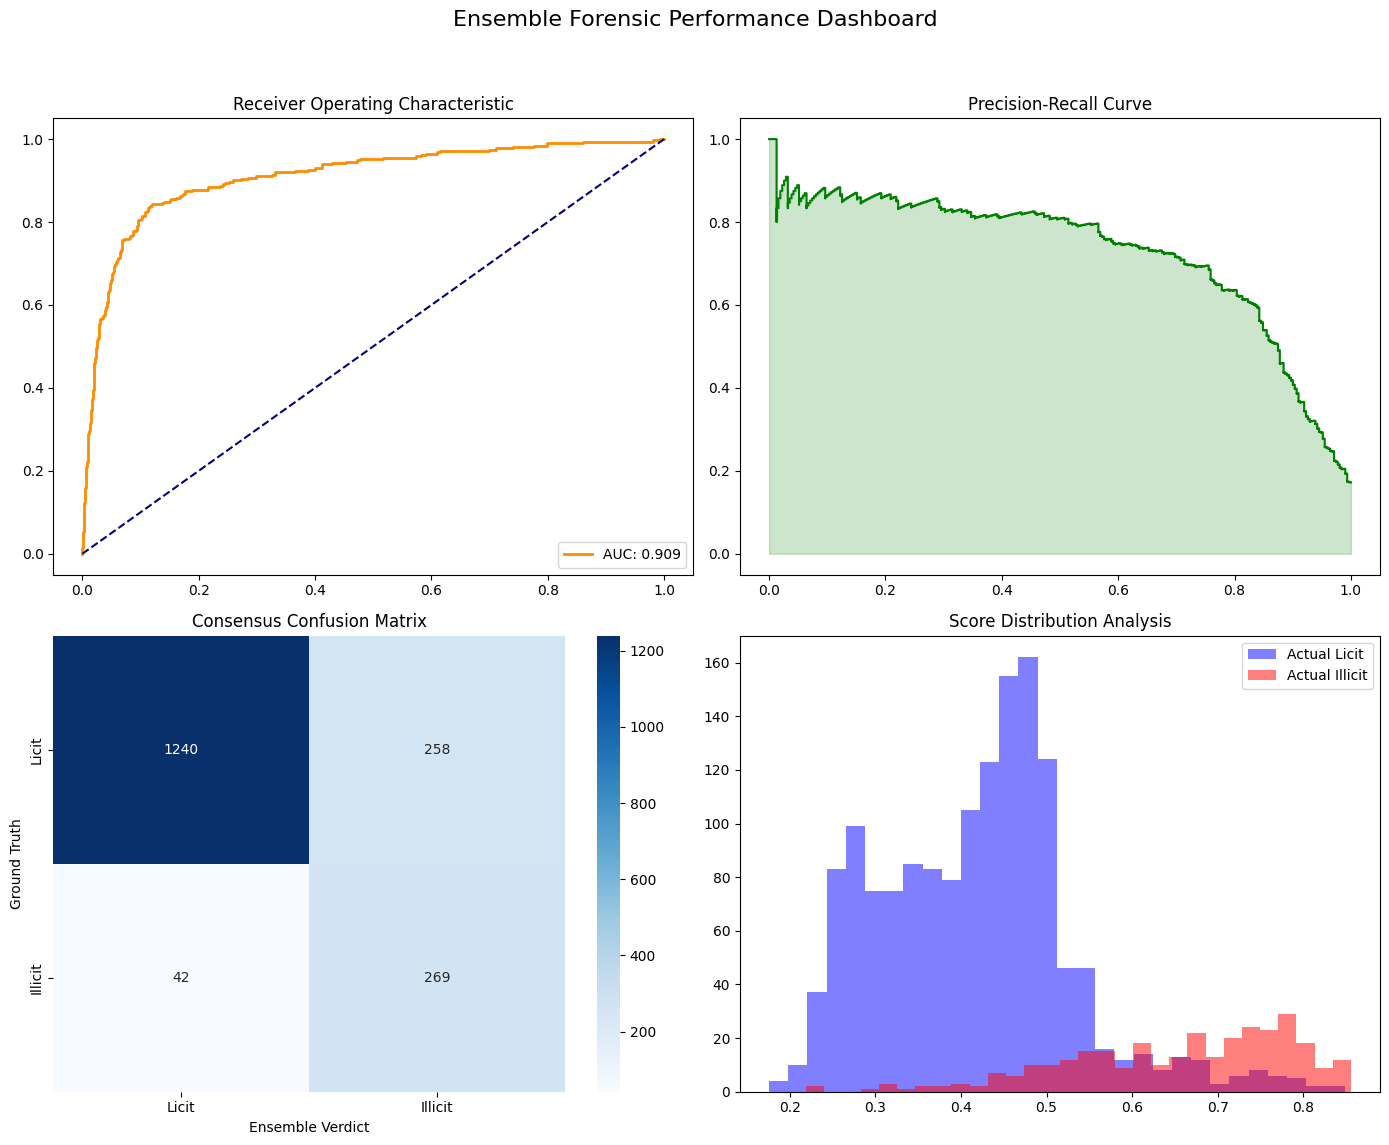

In [ ]:
import seaborn as sns # Adding seaborn makes the confusion matrix look much better

actuals, preds, confidences = [], [], []

with torch.inference_mode():
    for path, label in zip(test_images, test_labels):
        # Using our custom wrapper to keep things consistent
        res = classify_sample(path)
        actuals.append(label)
        preds.append(1 if res['verdict'] == "Tampered (Illicit)" else 0)
        confidences.append(res['distribution'][1])

# Convert to arrays for plotting
actuals, preds, confidences = np.array(actuals), np.array(preds), np.array(confidences)

# 2. Create a 2x2 Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Ensemble Forensic Performance Dashboard", fontsize=16)

# --- Subplot 1: ROC Curve ---
fpr, tpr, _ = roc_curve(actuals, confidences)
axes[0, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC: {roc_auc_score(actuals, confidences):.3f}")
axes[0, 0].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[0, 0].set_title("Receiver Operating Characteristic")
axes[0, 0].legend(loc="lower right")

# --- Subplot 2: Precision-Recall ---
prec, rec, _ = precision_recall_curve(actuals, confidences)
axes[0, 1].step(rec, prec, where='post', color='green')
axes[0, 1].set_title("Precision-Recall Curve")
axes[0, 1].fill_between(rec, prec, alpha=0.2, color='green')

# --- Subplot 3: Confusion Matrix (The Pro Way) ---
sns.heatmap(confusion_matrix(actuals, preds), annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['Licit', 'Illicit'], yticklabels=['Licit', 'Illicit'])
axes[1, 0].set_title("Consensus Confusion Matrix")
axes[1, 0].set_ylabel("Ground Truth")
axes[1, 0].set_xlabel("Ensemble Verdict")

# --- Subplot 4: Probability Distribution ---
axes[1, 1].hist(confidences[actuals == 0], bins=30, alpha=0.5, label='Actual Licit', color='blue')
axes[1, 1].hist(confidences[actuals == 1], bins=30, alpha=0.5, label='Actual Illicit', color='red')
axes[1, 1].set_title("Score Distribution Analysis")
axes[1, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [55]:
import torch
import torch.nn as nn
import timm
import numpy as np
import cv2
from google.colab import drive, files
from pathlib import Path

# --- Setup & Configuration ---
drive.mount("/content/drive", force_remount=True)
COMP_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Normalization constants (ImageNet defaults)
RGB_MEAN = [0.485, 0.456, 0.406]
RGB_STD = [0.229, 0.224, 0.225]

def prepare_tensor(img_path):
    """Loads, resizes, and normalizes image for the ensemble."""
    bgr_img = cv2.imread(img_path)
    rgb_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb_img, (224, 224)).astype(np.float32) / 255.0

    # Normalize and change shape to (C, H, W)
    normalized = (resized - RGB_MEAN) / (np.array(RGB_STD) + 1e-7)
    tensor = torch.from_numpy(normalized).permute(2, 0, 1).unsqueeze(0)
    return tensor.to(COMP_DEVICE).float()

# --- Model Architecture & Weight Loading ---
def build_backbones():
    """Initializes the four specific architectures used in the project."""
    arch_list = {
        "ViT": "vit_base_patch16_224",
        "EffNet": "efficientnet_b3",
        "ConvNeXt": "convnextv2_tiny",
        "Swin": "swin_tiny_patch4_window7_224"
    }

    loaded_models = {}
    for key, model_id in arch_list.items():
        loaded_models[key] = timm.create_model(model_id, pretrained=False, num_classes=2)
    return loaded_models

def inject_weights(model, weight_path):
    """Safely maps saved weights to the model, handling 'backbone' prefixes."""
    ckpt = torch.load(weight_path, map_location="cpu")
    # Clean keys dynamically
    adjusted_state = {k.replace("backbone.", ""): v for k, v in ckpt.items()}
    model.load_state_dict(adjusted_state, strict=False)
    model.to(COMP_DEVICE).eval()

# --- The Voting Engine ---
class ForensicEnsemble(nn.Module):
    def __init__(self, model_dict, ratio_map):
        super().__init__()
        self.sub_nets = nn.ModuleDict(model_dict)
        self.ratios = ratio_map

    def forward(self, x):
        # Accumulate weighted probabilities
        votes = [torch.softmax(net(x), dim=1) * self.ratios[name]
                 for name, net in self.sub_nets.items()]
        return torch.stack(votes).sum(dim=0)

# --- Initialization ---
base_models = build_backbones()

# Mapping weights to the drive paths
weight_paths = {
    "ViT": "/content/drive/MyDrive/morph_project/models/vit_advanced.pth",
    "EffNet": "/content/drive/MyDrive/morph_project/models/efficientnet_b3_tuned_baseline.pth",
    "ConvNeXt": "/content/drive/MyDrive/morph_project/models/convnextv2_best_224_finetuned.pth",
    "Swin": "/content/drive/MyDrive/morph_project/swin224_recall_tuned.pth"
}

for name, path in weight_paths.items():
    inject_weights(base_models[name], path)

# Final ensemble ratios based on performance tuning
final_weights = {"ViT": 0.3818, "EffNet": 0.2513, "ConvNeXt": 0.1461, "Swin": 0.2208}
ensemble_engine = ForensicEnsemble(base_models, final_weights).to(COMP_DEVICE).eval()

# --- High-Level Inference ---
def run_forensic_analysis(image_file):
    blob = prepare_tensor(image_file)
    with torch.inference_mode():
        dist = ensemble_engine(blob).squeeze().cpu().numpy()

    idx = np.argmax(dist)
    verdict = "TAMPERED (Illicit)" if idx == 1 else "AUTHENTIC (Licit)"
    confidence = dist[idx] * 100

    print(f"\n{'-'*30}\nFILE: {image_file}")
    print(f"VERDICT: {verdict}")
    print(f"CONFIDENCE: {confidence:.2f}%")
    print(f"RAW SCORES: {dist}\n{'-'*30}")

# --- Execution ---
print("\n[READY] Upload images to begin forensic analysis...")
upload_cache = files.upload()
for filename in upload_cache.keys():
    run_forensic_analysis(filename)

Mounted at /content/drive

[READY] Upload images to begin forensic analysis...


Saving casias1.png to casias1.png

------------------------------
FILE: casias1.png
VERDICT: TAMPERED (Illicit)
CONFIDENCE: 74.01%
RAW SCORES: [0.2598895  0.74011046]
------------------------------
